# Ngày 03/01/2024, 13g00 - 17g00, B2.503

#### - Pipeline for ML model
#### - K-Fold cross validation for model evaluation and selection

### data_for_training_regressors.csv

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/Chương 2/data_for_training_regressors.csv")

In [ ]:
df.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,6595.20,34989.00,32903.44,14864.07,13470.67,41159.13,13505.32,4381.51,No Idea,21192.19,73337.81
1,6365.13,34967.80,32693.55,15246.71,13561.08,40896.78,13072.25,5655.02,Disagree,20947.63,100390.67
2,6362.41,35256.18,32528.98,15070.97,13633.94,40887.57,12995.82,5045.68,Disagree,21316.31,84237.34
3,6413.18,35165.08,32635.15,15194.65,13547.27,41234.16,12828.18,5344.57,Strongly Agree,21152.82,88715.94
4,6616.16,35108.48,32835.18,15281.56,13874.98,40908.53,13202.14,4999.54,No Idea,21206.33,118108.62


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      997 non-null    float64
 1   X1      993 non-null    float64
 2   X2      991 non-null    float64
 3   X3      992 non-null    float64
 4   X4      998 non-null    float64
 5   X5      995 non-null    float64
 6   X6      993 non-null    float64
 7   X7      1000 non-null   float64
 8   X8      995 non-null    object 
 9   X9      996 non-null    float64
 10  Y       1000 non-null   float64
dtypes: float64(10), object(1)
memory usage: 86.1+ KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.isna().sum()

X0    3
X1    7
X2    9
X3    8
X4    2
X5    5
X6    7
X7    0
X8    5
X9    4
Y     0
dtype: int64

In [7]:
total_rows = df.shape[0]
missing_rows = df[df.isna().any(axis=1)].shape[0]
print(f"Tỷ lệ số dòng có dữ liệu bị thiếu: {missing_rows/total_rows}")

Tỷ lệ số dòng có dữ liệu bị thiếu: 0.049


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,6595.20,34989.00,32903.44,14864.07,13470.67,41159.13,13505.32,4381.51,No Idea,21192.19,73337.81
1,6365.13,34967.80,32693.55,15246.71,13561.08,40896.78,13072.25,5655.02,Disagree,20947.63,100390.67
2,6362.41,35256.18,32528.98,15070.97,13633.94,40887.57,12995.82,5045.68,Disagree,21316.31,84237.34
3,6413.18,35165.08,32635.15,15194.65,13547.27,41234.16,12828.18,5344.57,Strongly Agree,21152.82,88715.94
4,6616.16,35108.48,32835.18,15281.56,13874.98,40908.53,13202.14,4999.54,No Idea,21206.33,118108.62


In [10]:
numeric_cols = ["X0", "X1", "X2", "X3", "X4", "X5", "X6", "X7", "X9"]

In [11]:
df_melted = pd.melt(df[numeric_cols], var_name="Feature", value_name="Value")

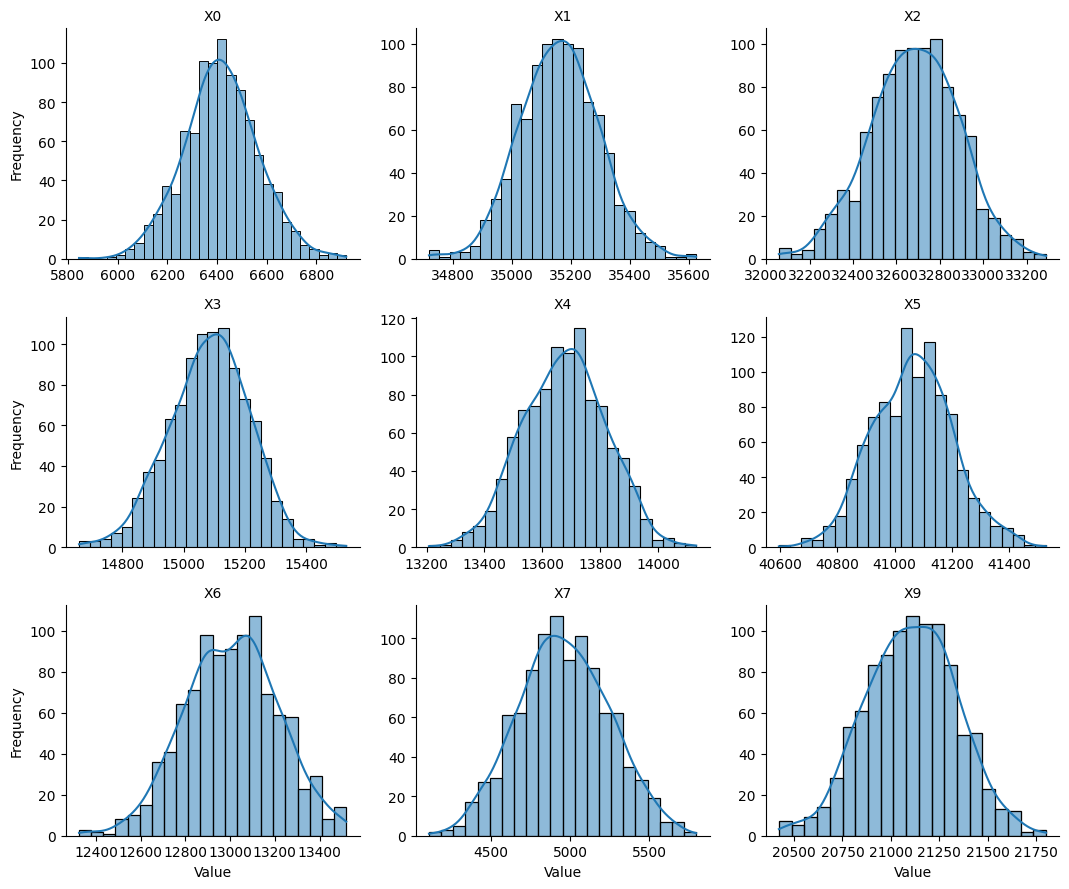

In [12]:
g = sns.FacetGrid(data=df_melted, col="Feature", col_wrap=3, 
                  sharex=False, sharey=False, aspect=1.2)

g.map(sns.histplot, 'Value', kde=True)

# Adjust the layout
g.set_titles('{col_name}')
g.set_axis_labels('Value', 'Frequency')
g.tight_layout()
plt.show()

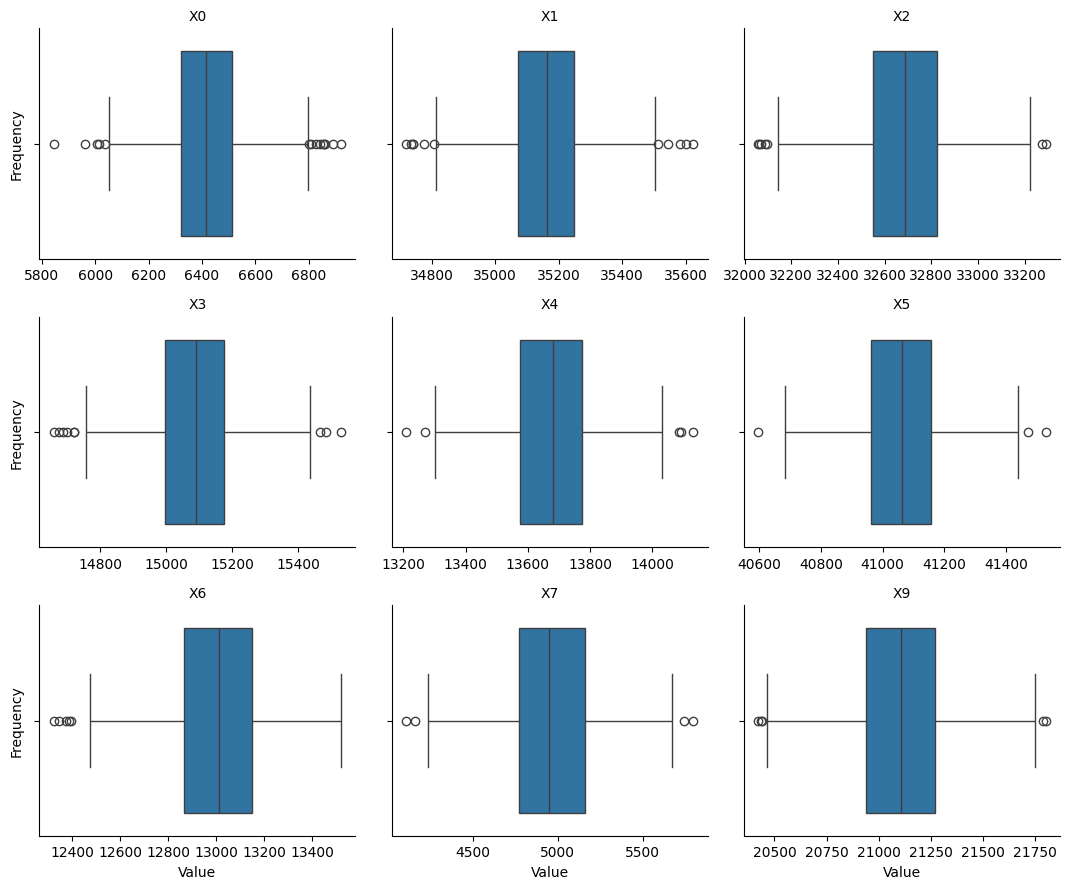

In [13]:
g = sns.FacetGrid(data=df_melted, col="Feature", col_wrap=3, 
                  sharex=False, sharey=False, aspect=1.2)

g.map(sns.boxplot, 'Value', order=None)

# Adjust the layout
g.set_titles('{col_name}')
g.set_axis_labels('Value', 'Frequency')
g.tight_layout()
plt.show()

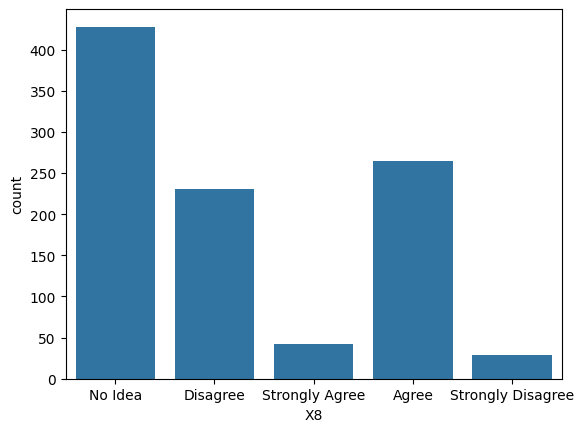

In [14]:
sns.countplot(data=df, x="X8")
plt.show()

#### Xây dựng mô hình dựa trên thuật toán hồi quy tuyến tính:
#### - Đặc trưng kiểu số: X0, X1, X2, X3, X4, X5, X6, X7, X9 (SimpleImputer/StandardScaler)
#### - Đặc trưng kiểu phân loại: X8 (SimpleImputer/OrdinalEncoder)
#### Strongly disagree:0 < Disagree:1 < No idea:2 < Agree:3 < Strongly Agree:4
#### - Biến mục tiêu (nhãn): Y

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression

In [16]:
cat_order = ["Strongly Disagree", "Disagree", "No Idea", "Agree", "Strongly Agree"]
cat_features = ["X8"]
cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), 
        ("encoder", OrdinalEncoder(categories=[cat_order]))
    ]
)

num_features = ["X0", "X1", "X2", "X3", "X4", "X5", "X6", "X7", "X9"]
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")), 
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[("cat_transformer", cat_transformer, cat_features), 
                  ("num_transformer", num_transformer, num_features)], 
    remainder="passthrough")

model_pl = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", LinearRegression())
    ]
)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
y = df["Y"].copy()
X = df.drop(columns=["Y"]).copy()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=503)

In [20]:
X_train.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9
637,6604.46,35259.80,32947.98,14919.82,13809.45,41317.41,13125.94,4751.87,Agree,21009.94
53,6280.01,35216.84,33031.74,15266.05,13641.41,41041.95,13263.03,4930.46,Agree,21086.47
977,6309.78,35363.57,32455.32,15149.20,13609.29,41154.84,12911.83,5588.74,Agree,21329.11
659,6361.48,35309.74,32568.30,14971.15,13833.02,41005.68,13082.63,5192.42,Disagree,20796.51
406,6387.58,35153.94,32721.64,14947.20,13502.37,41240.77,13264.93,4473.75,No Idea,21213.89


In [21]:
X_train.isna().sum()

X0    2
X1    5
X2    8
X3    5
X4    1
X5    2
X6    4
X7    0
X8    3
X9    3
dtype: int64

In [22]:
model_pl.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Strongly '
                                                                                               'Disagree',
                                                                                               'Disagree',
                                                                                               'No '
                                                                                               'Idea',
                                                                                               'Agree',
                                                                                               'Strongly '
                                                                                               'Agree']]))]),
                                                  ['X8']),
                                                 ('num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['X0', 'X1', 'X2', 'X3', 'X4',
                                                   'X5', 'X6', 'X7', 'X9'])])),
                ('regressor', LinearRegression())])

In [23]:
X_test.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9
744,6544.33,35008.29,32605.32,15036.15,13577.65,41182.60,13249.77,4709.75,Disagree,21198.32
930,6478.45,34773.88,32943.11,15145.12,13931.49,40945.55,13090.58,4866.98,No Idea,21438.70
430,6442.86,35353.34,32600.45,15066.99,13452.38,41207.98,12778.55,5251.59,Disagree,21123.24
28,6450.63,35107.15,32524.81,15183.04,13692.29,40870.18,13030.76,5013.30,Disagree,21279.42
309,6368.00,35208.55,32787.27,14895.06,13478.71,41329.75,12929.07,4753.46,Disagree,21267.44


In [24]:
X_test.isna().sum()

X0    1
X1    2
X2    1
X3    3
X4    1
X5    3
X6    3
X7    0
X8    2
X9    1
dtype: int64

In [25]:
y_pred = model_pl.predict(X_test)

In [26]:
model_pl.score(X_train, y_train)

0.9967499755780551

In [27]:
model_pl.score(X_test, y_test)

0.9956433053131692

In [28]:
from sklearn.metrics import r2_score

In [29]:
r2_score(y_test, y_pred)

0.9956433053131692

### K-Fold Cross validation

In [30]:
from sklearn.model_selection import cross_val_score, KFold

In [31]:
k = 20
kf = KFold(n_splits=k, shuffle=True, random_state=503)
cv_scores = cross_val_score(model_pl, X_train, y_train, scoring="r2", cv=kf)

In [32]:
cv_scores

array([0.97822707, 0.99928233, 0.9999762 , 0.99991446, 0.99996543,
       0.99975251, 0.98092851, 0.99669921, 0.99994772, 0.99998892,
       0.98726137, 0.99271279, 0.99868339, 0.99418292, 0.99940254,
       0.99998386, 0.99660024, 0.99840054, 0.99966913, 0.99997504])

In [33]:
cv_scores.mean()

np.float64(0.9960777091099178)

In [34]:
from sklearn.model_selection import cross_validate

In [35]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=503)
cv_results = cross_validate(model_pl, X_train, y_train, scoring="r2", cv=kf, 
                            return_train_score=True, return_estimator=True)

In [36]:
cv_results = pd.DataFrame(cv_results)

In [37]:
cv_results

,fit_time,score_time,estimator,test_score,train_score
0,0.040724,0.012492,"(ColumnTransformer(remainder='passthrough',\n ...",0.994756,0.997126
1,0.043583,0.016199,"(ColumnTransformer(remainder='passthrough',\n ...",0.994873,0.997023
2,0.020717,0.008384,"(ColumnTransformer(remainder='passthrough',\n ...",0.996148,0.996932
3,0.028286,0.010647,"(ColumnTransformer(remainder='passthrough',\n ...",0.997675,0.996551
4,0.017879,0.007343,"(ColumnTransformer(remainder='passthrough',\n ...",0.998586,0.996187


In [38]:
cv_results[["test_score", "train_score"]].mean()

test_score     0.996408
train_score    0.996764
dtype: float64

In [39]:
cv_results["diff"] = abs(cv_results["train_score"] - cv_results["test_score"])

### Tìm mô hình hiệu quả nhất: train score và validate score cao, khác biệt nhỏ nhất

In [40]:
cv_results.sort_values("diff")

,fit_time,score_time,estimator,test_score,train_score,diff
2,0.020717,0.008384,"(ColumnTransformer(remainder='passthrough',\n ...",0.996148,0.996932,0.000784
3,0.028286,0.010647,"(ColumnTransformer(remainder='passthrough',\n ...",0.997675,0.996551,0.001125
1,0.043583,0.016199,"(ColumnTransformer(remainder='passthrough',\n ...",0.994873,0.997023,0.002149
0,0.040724,0.012492,"(ColumnTransformer(remainder='passthrough',\n ...",0.994756,0.997126,0.002370
4,0.017879,0.007343,"(ColumnTransformer(remainder='passthrough',\n ...",0.998586,0.996187,0.002399


In [41]:
best_lr_model = cv_results["estimator"][2]

In [42]:
best_lr_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Strongly '
                                                                                               'Disagree',
                                                                                               'Disagree',
                                                                                               'No '
                                                                                               'Idea',
                                                                                               'Agree',
                                                                                               'Strongly '
                                                                                               'Agree']]))]),
                                                  ['X8']),
                                                 ('num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['X0', 'X1', 'X2', 'X3', 'X4',
                                                   'X5', 'X6', 'X7', 'X9'])])),
                ('regressor', LinearRegression())])

In [43]:
y_pred = best_lr_model.predict(X_test)

In [44]:
r2_score(y_test, y_pred)

0.9956380473106832

#### Nhận xét: R2 trên tập X_test là 0.9956, cho thấy các đặc trưng giải thích 99,56% sự biến thiên của biến mục tiêu. Mặt khác, giá trị này cũng xấp xỉ R2 của mô hình trên tập train (xem ở trên: validate score: 0.996408, train score: 0.996764).
#### Tóm lại: mô hình best_lr_model là mô hình hiệu quả nhất.